## 1.1: Data preparation

### imports

In [2]:
##Imports Cell

import random 
import pandas as pd 
from pathlib import Path

### Set the dataset path


In [3]:
data_path = Path("archive")

rock_files = []
paper_files = []
scissors_files = []


In [4]:
for image_path in (data_path / "rock").iterdir():
    if image_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        rock_files.append((str(image_path.relative_to(data_path)), "rock"))

for image_path in (data_path / "paper").iterdir():
    if image_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        paper_files.append((str(image_path.relative_to(data_path)), "paper"))

for image_path in (data_path / "scissors").iterdir():
    if image_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        scissors_files.append((str(image_path.relative_to(data_path)), "scissors"))

### Data-split 


In [5]:
##Check length of each list to ensure they are populated correctly, set random seed

print(len(rock_files), len(paper_files), len(scissors_files))

random.seed(42)

907 907 903


#### Splitting

In [6]:
def split_files(file_list):
    files = file_list.copy()
    random.shuffle(files)

    n = len(files)
    train_end = int(0.6 * n)
    devtest_end = int(0.8 * n)

    train_part = files[:train_end]
    devtest_part = files[train_end:devtest_end]
    test_part = files[devtest_end:]

    return train_part, devtest_part, test_part

rock_train, rock_devtest, rock_test = split_files(rock_files)
paper_train, paper_devtest, paper_test = split_files(paper_files)
scissors_train, scissors_devtest, scissors_test = split_files(scissors_files)


#### Combining and saving into csvs


In [7]:
train_files = rock_train + paper_train + scissors_train
devtest_files = rock_devtest + paper_devtest + scissors_devtest
test_files = rock_test + paper_test + scissors_test

random.shuffle(train_files)
random.shuffle(devtest_files)
random.shuffle(test_files)

train_df = pd.DataFrame(train_files, columns=["path", "label"])
devtest_df = pd.DataFrame(devtest_files, columns=["path", "label"])
test_df = pd.DataFrame(test_files, columns=["path", "label"])

print(len(train_df), len(devtest_df), len(test_df))

1629 543 545


In [8]:

train_df.to_csv("my_train.csv", index=False)
devtest_df.to_csv("my_devtest.csv", index=False)
test_df.to_csv("my_test.csv", index=False)

In [9]:
print(train_df["label"].value_counts())
print()

print(devtest_df["label"].value_counts())
print()

print(test_df["label"].value_counts())


label
rock        544
paper       544
scissors    541
Name: count, dtype: int64

label
paper       181
scissors    181
rock        181
Name: count, dtype: int64

label
rock        182
paper       182
scissors    181
Name: count, dtype: int64


## Task 1.1 explanation

I went through each class folder separately, shuffled the filenames using a fixed random seed, and split each class into 60% train, 20% devtest, and 20% test. I did the split class by class first, then combined the classes back together and shuffled each final split again before saving the CSV files.

I used this approach so the split stayed random without one class ending up overrepresented in one dataset. The class counts at the end show the three splits stayed basically balanced.

## 1.2 EDA

### Reload imports and file paths


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path("archive")

ref_train_df = pd.read_csv("train.csv")
ref_devtest_df = pd.read_csv("devtest.csv")
ref_test_df = pd.read_csv("test.csv")

In [11]:
print(ref_train_df["label"].value_counts())

label
paper       544
rock        544
scissors    541
Name: count, dtype: int64


### 1.2 part 1 

### Display one image from each dataset. We will be using a 3x3 grid for this

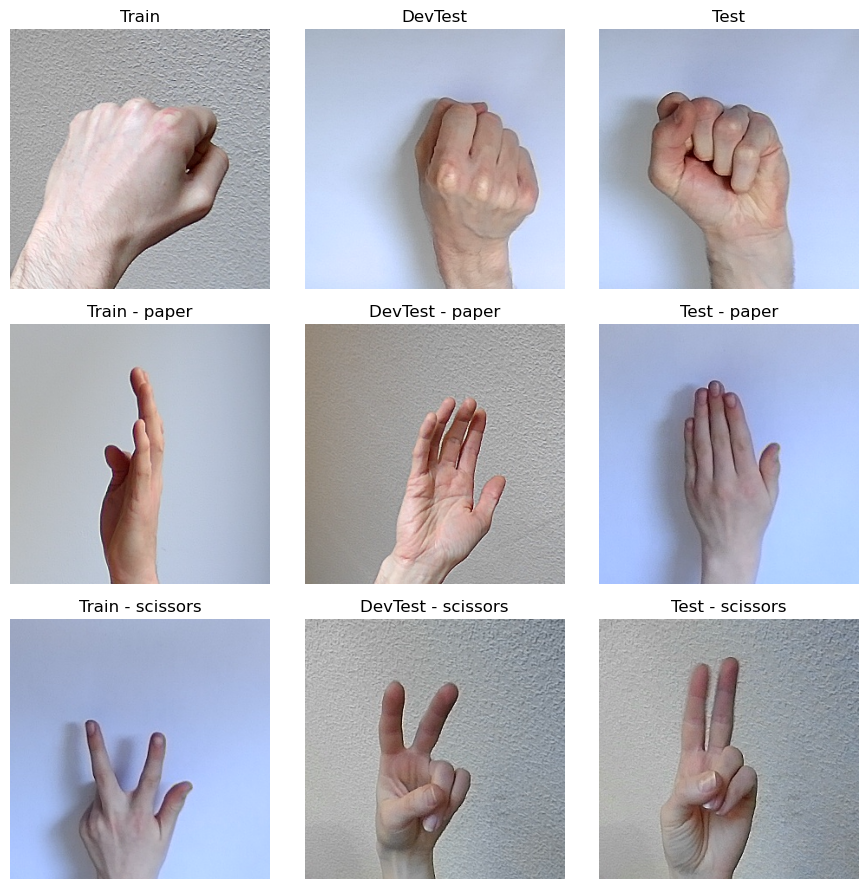

In [12]:
datasets = {
    "Train": ref_train_df,
    "DevTest": ref_devtest_df,
    "Test": ref_test_df
}
classes = ["rock", "paper", "scissors"]

fig,axes = plt.subplots(3, 3, figsize=(9,9))

for row, label in enumerate(classes):
    for col, (dataset_name, df) in enumerate(datasets.items()):
        sample_row = df[df["label"] == label].sample(1, random_state=42).iloc[0]
        image_path = data_path / sample_row["path"]
        image = plt.imread(image_path)

        axes[row, col].imshow(image)
        axes[row, col].set_title(f"{dataset_name} - {label}")
        axes[row, col].axis("off")

        if row == 0:
            axes[row, col].set_title(f"{dataset_name}", fontsize=12)
        if col == 0:
            axes[row, col].set_ylabel(f"{label}", fontsize=12)

plt.tight_layout()
plt.show()

### 1.2 part 2 determine the number of images in each class. 

In [13]:
counts_df = pd.DataFrame({
    "train": ref_train_df["label"].value_counts(),
    "devtest": ref_devtest_df["label"].value_counts(),
    "test": ref_test_df["label"].value_counts()
}).fillna(0).astype(int)

counts_df

,train,devtest,test
label,,,
paper,544,181,182
rock,544,181,182
scissors,541,180,182


### Task 1.2 explanation

For this part I used the provided `train.csv`, `devtest.csv`, and `test.csv` so that any mistake from Task 1.1 would not carry through into the rest of the notebook. To compare the datasets, I showed one example image per class in a 3x3 grid, which made it easy to look across train, devtest, and test side by side.

I also checked the class counts in each split. They are very similar, so there is no meaningful class imbalance between the datasets.

In [14]:
%pip install torch torchvision tqdm opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2.1 - Classification using ConvNets


In [15]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

In [16]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print("The device is", device)

The device is mps


In [17]:
data_path = Path("archive")

train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("devtest.csv")
test_df = pd.read_csv("test.csv")

CLASS_NAMES = sorted(train_df["label"].unique().tolist())
IMG_SHAPE = (50, 50)
IMG_CHANNELS = 3
BATCH_SIZE = 32

print(CLASS_NAMES)
print(len(train_df), len(val_df), len(test_df))

['paper', 'rock', 'scissors']
1629 542 546


In [18]:
class RPSDataset(Dataset):
    def __init__(self, data_pd, root_dir, class_names):
        self.fpaths = data_pd["path"].tolist()
        self.labels = data_pd["label"].tolist()
        self.root_dir = root_dir
        self.class_names = class_names
        self.targets = [self.class_names.index(label) for label in self.labels]

    def __len__(self):
        return len(self.fpaths)

    def __getitem__(self, ix):
        f = self.root_dir / self.fpaths[ix]
        target = self.targets[ix]

        im = cv2.imread(str(f))
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        im = cv2.resize(im, IMG_SHAPE)

        im = torch.tensor(im / 255.0).permute(2, 0, 1).float()
        target = torch.tensor(target).long()

        return im, target


In [19]:
train_loader = DataLoader(
    RPSDataset(train_df, data_path, CLASS_NAMES),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    RPSDataset(val_df, data_path, CLASS_NAMES),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    RPSDataset(test_df, data_path, CLASS_NAMES),
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [20]:
def get_model():
    model = nn.Sequential(
        nn.Conv2d(IMG_CHANNELS, 32, kernel_size=3),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Conv2d(32, 64, kernel_size=3),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Conv2d(64, 128, kernel_size=3),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(2048, len(CLASS_NAMES))
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters())

    return model, loss_fn, optimizer


In [21]:
@torch.no_grad()
def evaluate(loader, model, loss_fn):
    model.eval()

    losses = []
    accuracies = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        prediction = model(x)
        loss = loss_fn(prediction, y)

        losses.append(loss.item())

        is_correct = (prediction.argmax(dim=1) == y).float().cpu().numpy().tolist()
        accuracies.extend(is_correct)

    return np.mean(losses), np.mean(accuracies)


In [22]:
model, loss_fn, optimizer = get_model()

MAX_EPOCHS = 20

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_accuracy = 0
best_epoch = 0

for epoch in range(MAX_EPOCHS):
    model.train()

    epoch_losses = []
    epoch_accuracies = []

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS}", unit="batch")

    for x, y in progress_bar:
        x = x.to(device)
        y = y.to(device)

        prediction = model(x)
        loss = loss_fn(prediction, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

        is_correct = (prediction.argmax(dim=1) == y).float().cpu().numpy().tolist()
        epoch_accuracies.extend(is_correct)

    train_loss = np.mean(epoch_losses)
    train_accuracy = np.mean(epoch_accuracies)

    val_loss, val_accuracy = evaluate(val_loader, model, loss_fn)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss = {train_loss:.4f}, "
        f"Train Accuracy = {train_accuracy:.4f}, "
        f"Validation Loss = {val_loss:.4f}, "
        f"Validation Accuracy = {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_convnet.pth")


Epoch 1/20: 100%|██████████| 51/51 [00:04<00:00, 12.69batch/s]


Epoch 1: Train Loss = 1.0242, Train Accuracy = 0.4985, Validation Loss = 0.8711, Validation Accuracy = 0.6347


Epoch 2/20: 100%|██████████| 51/51 [00:02<00:00, 19.92batch/s]


Epoch 2: Train Loss = 0.8026, Train Accuracy = 0.6636, Validation Loss = 0.7827, Validation Accuracy = 0.6439


Epoch 3/20: 100%|██████████| 51/51 [00:02<00:00, 19.77batch/s]


...

Epoch 18: Train Loss = 0.0744, Train Accuracy = 0.9767, Validation Loss = 0.1158, Validation Accuracy = 0.9649


Epoch 19/20: 100%|██████████| 51/51 [00:02<00:00, 19.44batch/s]


Epoch 19: Train Loss = 0.0491, Train Accuracy = 0.9859, Validation Loss = 0.1233, Validation Accuracy = 0.9594


Epoch 20/20: 100%|██████████| 51/51 [00:02<00:00, 18.08batch/s]


Epoch 20: Train Loss = 0.0458, Train Accuracy = 0.9877, Validation Loss = 0.1236, Validation Accuracy = 0.9576


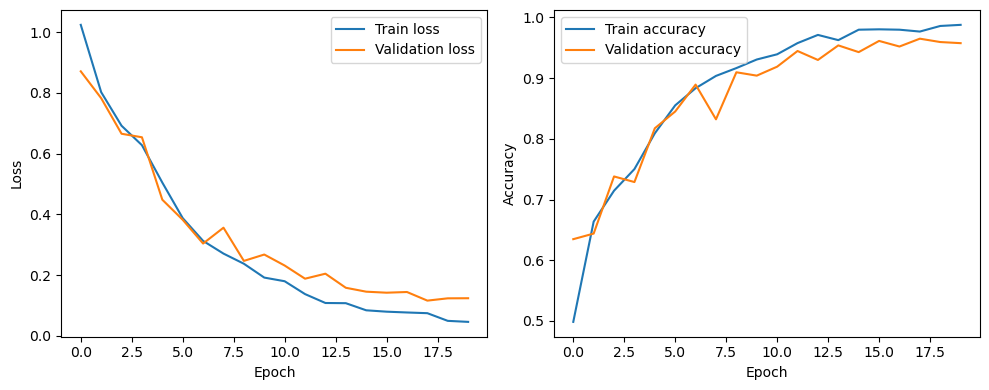

In [23]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train accuracy")
plt.plot(val_accuracies, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [24]:
model, loss_fn, optimizer = get_model()
model.load_state_dict(torch.load("best_convnet.pth"))

test_loss, test_accuracy = evaluate(test_loader, model, loss_fn)

print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_accuracy)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)


Best epoch: 18
Best validation accuracy: 0.9649446494464945
Test loss: 0.11904909120251735
Test accuracy: 0.9505494505494505


### 2.1 Explanation - Hyperparameter choices

I used a simple CNN with three convolution blocks. Each block has a convolution layer, max pooling, and ReLU, which matches the general setup we used in the practicals. I chose 32, 64, and 128 filters with a kernel size of 3 because it is a reasonable pattern that increases model capacity without making the network unnecessarily large for this task.

I resized the images to 50 x 50 so the input shape stayed consistent, and I trained with batch size 32, cross-entropy loss, and Adam. I did not do an exhaustive hyperparameter search. I started from a standard setup based on the Week 4 material, then judged it using the training and validation results.

To decide when to stop training, I tracked validation accuracy on `devtest.csv` and kept the model from the epoch with the best validation score.

### 2.1 Explaination - Overfitting

There is some mild overfitting near the later epochs. The training loss keeps falling and the training accuracy keeps improving, but the validation improvement slows down and becomes less consistent. That usually means the model is starting to fit the training data a bit more tightly than the validation data.

I would not call it severe though. The validation accuracy still got up to 0.9631, and the final test accuracy was 0.9634, so the model still generalised well overall.

## 2.2 - Using a pre-trained model (MobileNet)


In [25]:

## Imports 
from torchvision import models, transforms

imagenet_normalise = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

In [26]:
class RPSPretrainedDataset(Dataset):
    def __init__(self, data_pd, root_dir, class_names):
        self.fpaths = data_pd["path"].tolist()
        self.labels = data_pd["label"].tolist()
        self.root_dir = root_dir
        self.class_names = class_names
        self.targets = [self.class_names.index(label) for label in self.labels]

    def __len__(self):
        return len(self.fpaths)

    def __getitem__(self, ix):
        f = self.root_dir / self.fpaths[ix]
        target = self.targets[ix]

        im = cv2.imread(str(f))
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        im = cv2.resize(im, IMG_SHAPE)

        im = torch.tensor(im / 255.0, dtype=torch.float32).permute(2, 0, 1)
        im = imagenet_normalise(im)

        target = torch.tensor(target).long()
        return im, target


In [27]:
## Create new loaders for MobileNet 

train_loader_pre = DataLoader(
    RPSPretrainedDataset(train_df, data_path, CLASS_NAMES),
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader_pre = DataLoader(
    RPSPretrainedDataset(val_df, data_path, CLASS_NAMES),
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_loader_pre = DataLoader(
    RPSPretrainedDataset(test_df, data_path, CLASS_NAMES),
    batch_size=BATCH_SIZE,
    shuffle=False
)

#### Load MobileNet

In [28]:
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)


In [29]:
## Freeze the model 
for param in mobilenet.parameters():
    param.requires_grad = False

mobilenet.classifier[1] = nn.Linear(
    mobilenet.classifier[1].in_features,
    len(CLASS_NAMES)
)

mobilenet = mobilenet.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(mobilenet.classifier.parameters())


### Training 

In [30]:
model = mobilenet

MAX_EPOCHS = 30

train_losses_pre = []
train_accuracies_pre = []
val_losses_pre = []
val_accuracies_pre = []

best_val_accuracy_pre = 0
best_epoch_pre = 0

for epoch in range(MAX_EPOCHS):
    model.train()

    epoch_losses = []
    epoch_accuracies = []

    progress_bar = tqdm(train_loader_pre, desc=f"Epoch {epoch+1}/{MAX_EPOCHS}", unit="batch")

    for x, y in progress_bar:
        x = x.to(device)
        y = y.to(device)

        prediction = model(x)
        loss = loss_fn(prediction, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

        is_correct = (prediction.argmax(dim=1) == y).float().cpu().numpy().tolist()
        epoch_accuracies.extend(is_correct)

    train_loss = np.mean(epoch_losses)
    train_accuracy = np.mean(epoch_accuracies)

    val_loss, val_accuracy = evaluate(val_loader_pre, model, loss_fn)

    train_losses_pre.append(train_loss)
    train_accuracies_pre.append(train_accuracy)
    val_losses_pre.append(val_loss)
    val_accuracies_pre.append(val_accuracy)

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss = {train_loss:.4f}, "
        f"Train Accuracy = {train_accuracy:.4f}, "
        f"Validation Loss = {val_loss:.4f}, "
        f"Validation Accuracy = {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy_pre:
        best_val_accuracy_pre = val_accuracy
        best_epoch_pre = epoch + 1
        torch.save(model.state_dict(), "best_mobilenet.pth")


Epoch 1/30: 100%|██████████| 51/51 [00:03<00:00, 15.75batch/s]


Epoch 1: Train Loss = 0.8776, Train Accuracy = 0.5961, Validation Loss = 0.6864, Validation Accuracy = 0.7675


Epoch 2/30: 100%|██████████| 51/51 [00:02<00:00, 18.43batch/s]


Epoch 2: Train Loss = 0.6526, Train Accuracy = 0.7643, Validation Loss = 0.5985, Validation Accuracy = 0.7934


Epoch 3/30: 100%|██████████| 51/51 [00:02<00:00, 18.49batch/s]


...

Epoch 28: Train Loss = 0.3506, Train Accuracy = 0.8594, Validation Loss = 0.3909, Validation Accuracy = 0.8469


Epoch 29/30: 100%|██████████| 51/51 [00:03<00:00, 14.73batch/s]


Epoch 29: Train Loss = 0.3671, Train Accuracy = 0.8570, Validation Loss = 0.3951, Validation Accuracy = 0.8616


Epoch 30/30: 100%|██████████| 51/51 [00:03<00:00, 14.41batch/s]


Epoch 30: Train Loss = 0.3747, Train Accuracy = 0.8551, Validation Loss = 0.4156, Validation Accuracy = 0.8450


### Plot and test

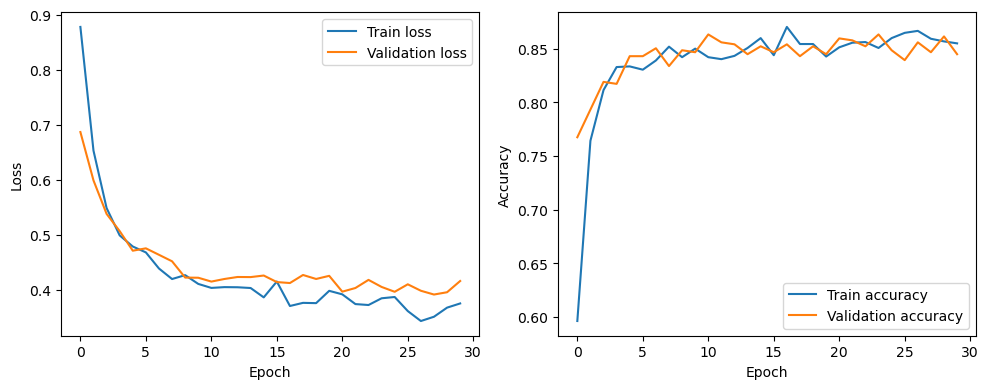

In [31]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses_pre, label="Train loss")
plt.plot(val_losses_pre, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies_pre, label="Train accuracy")
plt.plot(val_accuracies_pre, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [32]:
model = mobilenet
model.load_state_dict(torch.load("best_mobilenet.pth"))

test_loss_pre, test_accuracy_pre = evaluate(test_loader_pre, model, loss_fn)

print("Best epoch:", best_epoch_pre)
print("Best validation accuracy:", best_val_accuracy_pre)
print("Test loss:", test_loss_pre)
print("Test accuracy:", test_accuracy_pre)


Best epoch: 11
Best validation accuracy: 0.8634686346863468
Test loss: 0.42819106330474216
Test accuracy: 0.8388278388278388


## 2.2 Explaination - 

For the second model, I used MobileNetV2 pre-trained on ImageNet. Instead of learning everything from scratch, I replaced the final classification layer so it could predict the three classes in this task, then froze the pre-trained weights and trained only the new final layer.

I kept the same train, validation, and test split from Task 2.1 so the comparison was fair. I also used ImageNet normalisation because MobileNet was originally trained that way. The model I kept was the one with the best validation accuracy.

Compared with the custom ConvNet, MobileNet trained more smoothly and showed less obvious overfitting, but it still finished with a lower test accuracy. The ConvNet reached 0.9634 on the test set, while MobileNet reached 0.8388, so the ConvNet was clearly the better model here.

# Task 2.3 - Error Analysis

In [33]:
@torch.no_grad()
def get_predictions(loader, model):
    model.eval()

    predictions = []
    targets = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        output = model(x)
        predictions.extend(output.argmax(dim=1).cpu().numpy().tolist())
        targets.extend(y.cpu().numpy().tolist())

    return predictions, targets

In [34]:
def make_results_df(base_df, predictions, targets):
    results_df = base_df.copy().reset_index(drop=True)

    results_df["actual_index"] = targets
    results_df["predicted_index"] = predictions
    results_df["actual_label"] = [CLASS_NAMES[i] for i in targets]
    results_df["predicted_label"] = [CLASS_NAMES[i] for i in predictions]
    results_df["correct"] = results_df["actual_label"] == results_df["predicted_label"]

    return results_df


### Reload both saved models

In [35]:
convnet_model, _, _ = get_model()
convnet_model.load_state_dict(torch.load("best_convnet.pth"))
convnet_model = convnet_model.to(device)

mobilenet_model = models.mobilenet_v2(weights=None)
mobilenet_model.classifier[1] = nn.Linear(
    mobilenet_model.classifier[1].in_features,
    len(CLASS_NAMES)
)
mobilenet_model.load_state_dict(torch.load("best_mobilenet.pth"))
mobilenet_model = mobilenet_model.to(device)


### Get predictions and build tables

In [36]:
convnet_predictions, convnet_targets = get_predictions(test_loader, convnet_model)
mobilenet_predictions, mobilenet_targets = get_predictions(test_loader_pre, mobilenet_model)

convnet_results = make_results_df(test_df, convnet_predictions, convnet_targets)
mobilenet_results = make_results_df(test_df, mobilenet_predictions, mobilenet_targets)


### Confusion matrices

In [37]:
def get_confusion_df(results_df):
    cm = pd.crosstab(
        results_df["actual_label"],
        results_df["predicted_label"]
    )

    cm = cm.reindex(index=CLASS_NAMES, columns=CLASS_NAMES, fill_value=0)
    return cm


In [38]:
def plot_confusion_matrix(cm_df, title):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm_df.values, cmap="Blues")

    plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES)
    plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)

    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            plt.text(j, i, cm_df.iloc[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()


In [39]:
convnet_cm = get_confusion_df(convnet_results)
mobilenet_cm = get_confusion_df(mobilenet_results)

print("ConvNet confusion matrix")
print(convnet_cm)
print()

print("MobileNet confusion matrix")
print(mobilenet_cm)


ConvNet confusion matrix
predicted_label  paper  rock  scissors
actual_label                          
paper              174     3         5
rock                 5   173         4
scissors             6     4       172

MobileNet confusion matrix
predicted_label  paper  rock  scissors
actual_label                          
paper              151    11        20
rock                 6   156        20
scissors            19    12       151


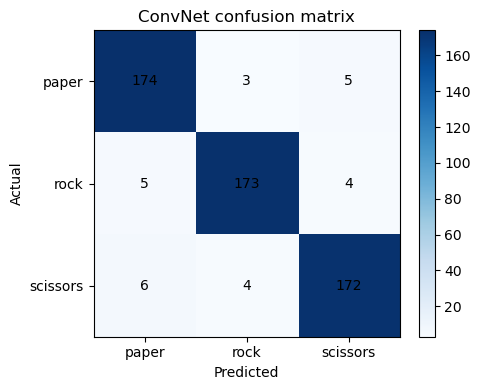

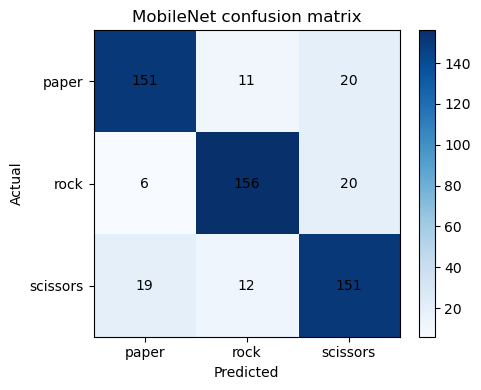

In [40]:
plot_confusion_matrix(convnet_cm, "ConvNet confusion matrix")
plot_confusion_matrix(mobilenet_cm, "MobileNet confusion matrix")


### Find most common wrong prediction

In [41]:
def get_error_counts(results_df):
    errors = results_df[results_df["correct"] == False]

    error_counts = (
        errors.groupby(["actual_label", "predicted_label"])
        .size()
        .sort_values(ascending=False)
    )

    return error_counts


In [42]:
convnet_error_counts = get_error_counts(convnet_results)
mobilenet_error_counts = get_error_counts(mobilenet_results)

print("ConvNet error counts")
print(convnet_error_counts)
print()

print("MobileNet error counts")
print(mobilenet_error_counts)


ConvNet error counts
actual_label  predicted_label
scissors      paper              6
paper         scissors           5
rock          paper              5
              scissors           4
scissors      rock               4
paper         rock               3
dtype: int64

MobileNet error counts
actual_label  predicted_label
paper         scissors           20
rock          scissors           20
scissors      paper              19
              rock               12
paper         rock               11
rock          paper               6
dtype: int64


In [43]:
convnet_top_actual, convnet_top_pred = convnet_error_counts.index[0]
mobilenet_top_actual, mobilenet_top_pred = mobilenet_error_counts.index[0]

print("ConvNet most common error:", convnet_top_actual, "->", convnet_top_pred)
print("MobileNet most common error:", mobilenet_top_actual, "->", mobilenet_top_pred)


ConvNet most common error: scissors -> paper
MobileNet most common error: paper -> scissors


In [44]:
def show_error_examples(results_df, actual_label, predicted_label, title):
    subset = results_df[
        (results_df["actual_label"] == actual_label) &
        (results_df["predicted_label"] == predicted_label)
    ].head(5)

    n = len(subset)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))

    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, subset.iterrows()):
        image = plt.imread(data_path / row["path"])
        ax.imshow(image)
        ax.set_title(f"Actual: {row['actual_label']}\nPred: {row['predicted_label']}")
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


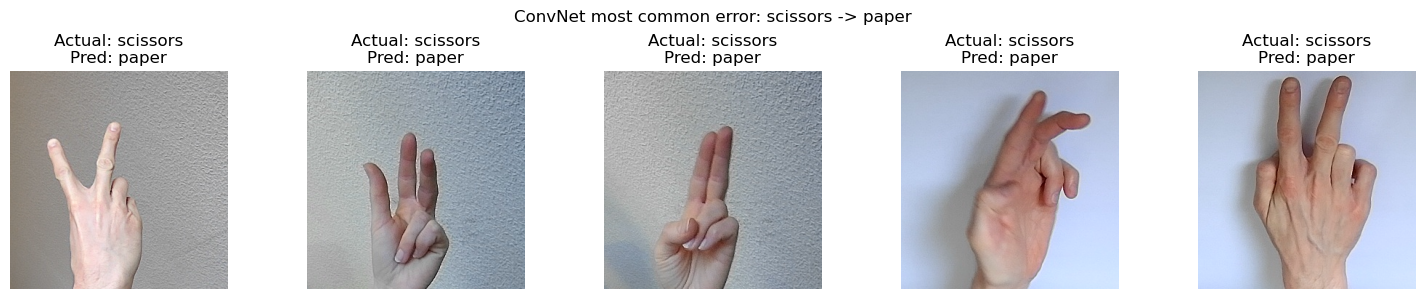

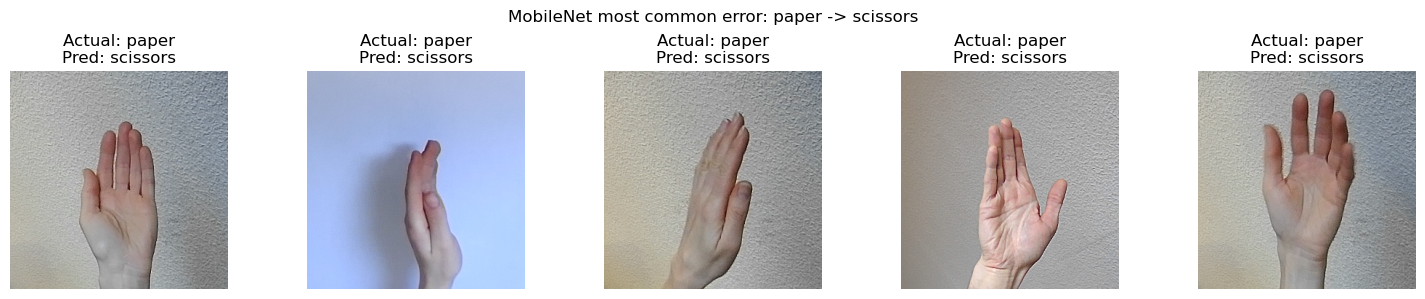

In [45]:
show_error_examples(
    convnet_results,
    convnet_top_actual,
    convnet_top_pred,
    f"ConvNet most common error: {convnet_top_actual} -> {convnet_top_pred}"
)

show_error_examples(
    mobilenet_results,
    mobilenet_top_actual,
    mobilenet_top_pred,
    f"MobileNet most common error: {mobilenet_top_actual} -> {mobilenet_top_pred}"
)


### 2.3 - Explanation 

I used the confusion matrices to see not just how accurate each model was overall, but exactly where the mistakes were happening. The ConvNet performed better because most predictions stayed on the main diagonal, while MobileNet had more off-diagonal errors across all three classes.

For the ConvNet, the most common error was `scissors -> paper` with 6 cases. For MobileNet, the most common error was `paper -> scissors` with 20 cases, which is a much larger error count. Looking at the example images, both models seemed to struggle more when the hand shape was less clean or the pose was a bit awkward, but MobileNet was clearly less consistent on those edge cases.




## Task 3.1 Generate new images


In [46]:
import cv2
import time
import random
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [47]:
webcam_data_path = Path("webcam_data")

for label in ["rock", "paper", "scissors"]:
    (webcam_data_path / label).mkdir(parents=True, exist_ok=True)

print("Folders created.")


Folders created.


In [48]:
def capture_images(label, num_images=100, delay=0.5, camera_index=0):
    save_dir = webcam_data_path / label
    cap = cv2.VideoCapture(camera_index)

    if not cap.isOpened():
        print("Could not open webcam.")
        return

    print(f"Capturing images for: {label}")
    print("Press s to start capturing")
    print("Press q to quit early")

    count = 0
    started = False
    last_capture_time = time.time()

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Could not read frame.")
            break

        frame = cv2.flip(frame, 1)

        display_frame = frame.copy()
        cv2.putText(display_frame, f"Label: {label}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.putText(display_frame, f"Saved: {count}/{num_images}", (10, 70),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        cv2.imshow("Webcam Capture", display_frame)

        key = cv2.waitKey(1) & 0xFF

        if key == ord("s"):
            started = True
            last_capture_time = time.time()

        if key == ord("q"):
            break

        if started and count < num_images:
            current_time = time.time()

            if current_time - last_capture_time >= delay:
                filename = save_dir / f"{label}_{count:03d}.png"
                cv2.imwrite(str(filename), frame)
                count += 1
                last_capture_time = current_time

        if count >= num_images:
            break

    cap.release()
    cv2.destroyAllWindows()
    print(f"Finished {label}: saved {count} images")


In [49]:
capture_images("rock", num_images=100, delay=0.5, camera_index=0)


Capturing images for: rock
Press s to start capturing
Press q to quit early
Finished rock: saved 0 images


In [50]:
capture_images("paper", num_images=100, delay=0.5, camera_index=0)


Capturing images for: paper
Press s to start capturing
Press q to quit early
Finished paper: saved 0 images


In [51]:
capture_images("scissors", num_images=100, delay=0.5, camera_index=0)



Capturing images for: scissors
Press s to start capturing
Press q to quit early
Finished scissors: saved 0 images


In [52]:
for label in ["rock", "paper", "scissors"]:
    files = list((webcam_data_path / label).glob("*.png"))
    print(label, len(files))


rock 100
paper 100
scissors 100


### Split 50/25/25

In [53]:
rock_files = []
paper_files = []
scissors_files = []

for image_path in (webcam_data_path / "rock").iterdir():
    if image_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        rock_files.append((str(image_path), "rock"))

for image_path in (webcam_data_path / "paper").iterdir():
    if image_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        paper_files.append((str(image_path), "paper"))

for image_path in (webcam_data_path / "scissors").iterdir():
    if image_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        scissors_files.append((str(image_path), "scissors"))


In [54]:
random.seed(42)

def split_files(file_list):
    files = file_list.copy()
    random.shuffle(files)

    n = len(files)
    train_end = int(0.5 * n)
    devtest_end = int(0.75 * n)

    train_part = files[:train_end]
    devtest_part = files[train_end:devtest_end]
    test_part = files[devtest_end:]

    return train_part, devtest_part, test_part

rock_train, rock_devtest, rock_test = split_files(rock_files)
paper_train, paper_devtest, paper_test = split_files(paper_files)
scissors_train, scissors_devtest, scissors_test = split_files(scissors_files)

new_train_files = rock_train + paper_train + scissors_train
new_devtest_files = rock_devtest + paper_devtest + scissors_devtest
new_test_files = rock_test + paper_test + scissors_test

random.shuffle(new_train_files)
random.shuffle(new_devtest_files)
random.shuffle(new_test_files)

new_train_df = pd.DataFrame(new_train_files, columns=["path", "label"])
new_devtest_df = pd.DataFrame(new_devtest_files, columns=["path", "label"])
new_test_df = pd.DataFrame(new_test_files, columns=["path", "label"])

new_train_df.to_csv("new_train.csv", index=False)
new_devtest_df.to_csv("new_devtest.csv", index=False)
new_test_df.to_csv("new_test.csv", index=False)

print(len(new_train_df), len(new_devtest_df), len(new_test_df))


150 75 75


### Preview

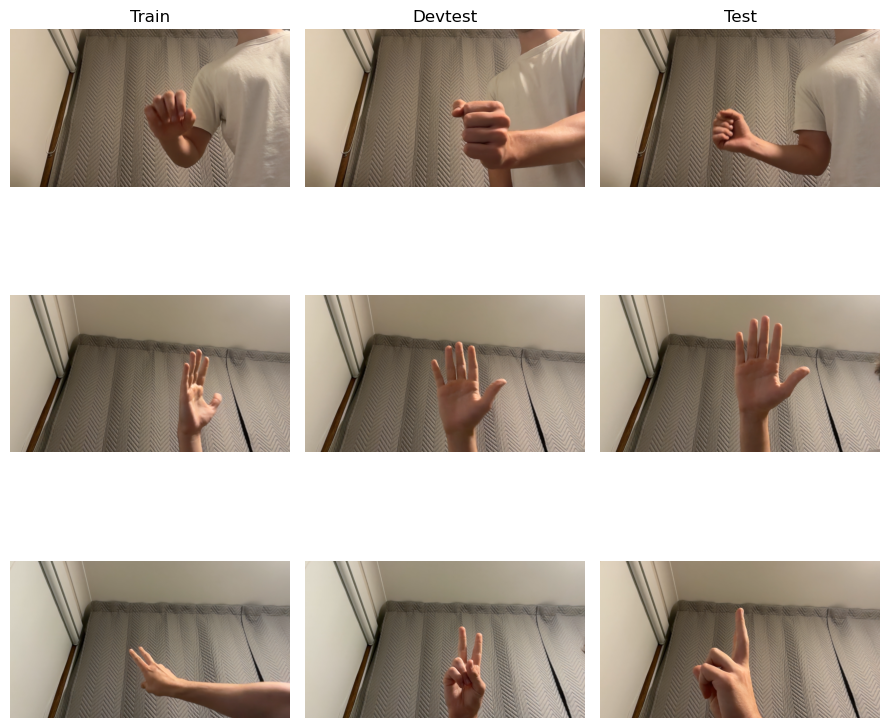

In [55]:
new_datasets = {
    "Train": new_train_df,
    "Devtest": new_devtest_df,
    "Test": new_test_df
}

classes = ["rock", "paper", "scissors"]

fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for row, label in enumerate(classes):
    for col, (dataset_name, df) in enumerate(new_datasets.items()):
        sample_row = df[df["label"] == label].iloc[0]
        image = plt.imread(sample_row["path"])

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if row == 0:
            axes[row, col].set_title(dataset_name)

        if col == 0:
            axes[row, col].set_ylabel(label)

plt.tight_layout()
plt.show()


In [56]:
for dataset_name, df in new_datasets.items():
    print(dataset_name)
    print(df["label"].value_counts())
    print()


Train
label
scissors    50
paper       50
rock        50
Name: count, dtype: int64

Devtest
label
paper       25
rock        25
scissors    25
Name: count, dtype: int64

Test
label
paper       25
rock        25
scissors    25
Name: count, dtype: int64



### 3.1 Explanation

I collected the new images using my webcam and saved them into separate folders for `rock`, `paper`, and `scissors` inside `webcam_data`. The capture function takes the class label as input and writes each image into the matching folder, so the label is determined at the time the image is saved rather than being sorted manually afterwards.

To keep the folders correct, I captured one class at a time and only ran the function for that class while making that hand sign. After collecting the images, I checked the file counts for each folder, then split them into train, devtest, and test using the same class-by-class shuffling approach as before.


## 3.2 - Fine-tuning and testing

In [57]:
new_train_df = pd.read_csv("new_train.csv")
new_devtest_df = pd.read_csv("new_devtest.csv")
new_test_df = pd.read_csv("new_test.csv")

webcam_root = Path(".")


In [58]:
new_train_loader = DataLoader(
    RPSDataset(new_train_df, webcam_root, CLASS_NAMES),
    batch_size=BATCH_SIZE,
    shuffle=True
)

new_devtest_loader = DataLoader(
    RPSDataset(new_devtest_df, webcam_root, CLASS_NAMES),
    batch_size=BATCH_SIZE,
    shuffle=False
)

new_test_loader = DataLoader(
    RPSDataset(new_test_df, webcam_root, CLASS_NAMES),
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [59]:
baseline_model, baseline_loss_fn, _ = get_model()
baseline_model.load_state_dict(torch.load("best_convnet.pth"))
baseline_model = baseline_model.to(device)


In [60]:
original_test_loss_before, original_test_accuracy_before = evaluate(
    test_loader, baseline_model, baseline_loss_fn
)

new_test_loss_before, new_test_accuracy_before = evaluate(
    new_test_loader, baseline_model, baseline_loss_fn
)

print("Before fine-tuning")
print("Original test loss:", original_test_loss_before)
print("Original test accuracy:", original_test_accuracy_before)
print("New test loss:", new_test_loss_before)
print("New test accuracy:", new_test_accuracy_before)


Before fine-tuning
Original test loss: 0.11904909120251735
Original test accuracy: 0.9505494505494505
New test loss: 3.3452486991882324
New test accuracy: 0.18666666666666668


In [61]:
original_test_loss_before, original_test_accuracy_before = evaluate(
    test_loader, baseline_model, baseline_loss_fn
)

new_test_loss_before, new_test_accuracy_before = evaluate(
    new_test_loader, baseline_model, baseline_loss_fn
)

print("Before fine-tuning")
print("Original test loss:", original_test_loss_before)
print("Original test accuracy:", original_test_accuracy_before)
print("New test loss:", new_test_loss_before)
print("New test accuracy:", new_test_accuracy_before)


Before fine-tuning
Original test loss: 0.11904909120251735
Original test accuracy: 0.9505494505494505
New test loss: 3.3452486991882324
New test accuracy: 0.18666666666666668


In [62]:
finetune_model, finetune_loss_fn, _ = get_model()
finetune_model.load_state_dict(torch.load("best_convnet.pth"))
finetune_model = finetune_model.to(device)

finetune_optimizer = Adam(finetune_model.parameters(), lr=0.0001)


In [64]:
FINETUNE_EPOCHS = 20

finetune_train_losses = []
finetune_train_accuracies = []
finetune_val_losses = []
finetune_val_accuracies = []

best_finetune_val_accuracy = 0
best_finetune_epoch = 0

for epoch in range(FINETUNE_EPOCHS):
    finetune_model.train()

    epoch_losses = []
    epoch_accuracies = []

    progress_bar = tqdm(new_train_loader, desc=f"Epoch {epoch+1}/{FINETUNE_EPOCHS}", unit="batch")

    for x, y in progress_bar:
        x = x.to(device)
        y = y.to(device)

        prediction = finetune_model(x)
        loss = finetune_loss_fn(prediction, y)

        finetune_optimizer.zero_grad()
        loss.backward()
        finetune_optimizer.step()

        epoch_losses.append(loss.item())

        is_correct = (prediction.argmax(dim=1) == y).float().cpu().numpy().tolist()
        epoch_accuracies.extend(is_correct)

    train_loss = np.mean(epoch_losses)
    train_accuracy = np.mean(epoch_accuracies)

    val_loss, val_accuracy = evaluate(new_devtest_loader, finetune_model, finetune_loss_fn)

    finetune_train_losses.append(train_loss)
    finetune_train_accuracies.append(train_accuracy)
    finetune_val_losses.append(val_loss)
    finetune_val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss = {train_loss:.4f}, "
        f"Train Accuracy = {train_accuracy:.4f}, "
        f"Validation Loss = {val_loss:.4f}, "
        f"Validation Accuracy = {val_accuracy:.4f}"
    )

    if val_accuracy > best_finetune_val_accuracy:
        best_finetune_val_accuracy = val_accuracy
        best_finetune_epoch = epoch + 1
        torch.save(finetune_model.state_dict(), "best_convnet_finetuned.pth")


Epoch 1/20: 100%|██████████| 5/5 [00:03<00:00,  1.42batch/s]


Epoch 1: Train Loss = 2.2188, Train Accuracy = 0.3333, Validation Loss = 2.1103, Validation Accuracy = 0.4800


Epoch 2/20: 100%|██████████| 5/5 [00:03<00:00,  1.50batch/s]


Epoch 2: Train Loss = 1.8677, Train Accuracy = 0.5000, Validation Loss = 1.8918, Validation Accuracy = 0.5067


Epoch 3/20: 100%|██████████| 5/5 [00:03<00:00,  1.51batch/s]


...

Epoch 18: Train Loss = 0.2750, Train Accuracy = 0.8800, Validation Loss = 0.3993, Validation Accuracy = 0.8800


Epoch 19/20: 100%|██████████| 5/5 [00:03<00:00,  1.47batch/s]


Epoch 19: Train Loss = 0.2605, Train Accuracy = 0.9000, Validation Loss = 0.3737, Validation Accuracy = 0.8933


Epoch 20/20: 100%|██████████| 5/5 [00:03<00:00,  1.47batch/s]


Epoch 20: Train Loss = 0.2383, Train Accuracy = 0.9067, Validation Loss = 0.3514, Validation Accuracy = 0.9067


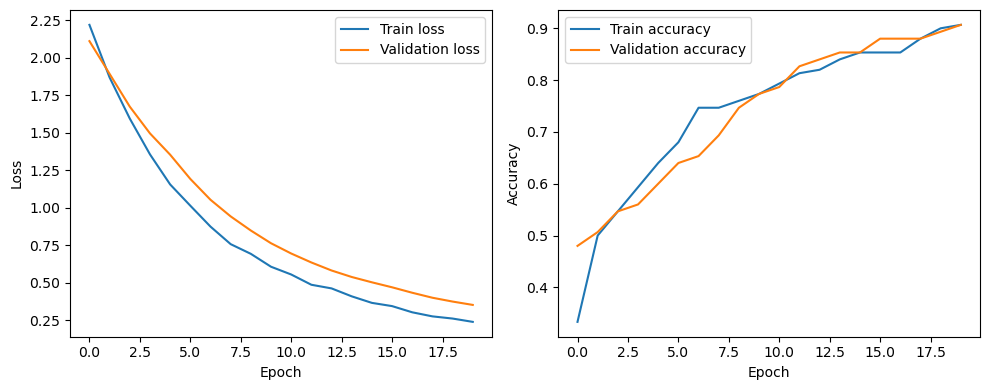

In [65]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(finetune_train_losses, label="Train loss")
plt.plot(finetune_val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(finetune_train_accuracies, label="Train accuracy")
plt.plot(finetune_val_accuracies, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [66]:
finetune_model, finetune_loss_fn, _ = get_model()
finetune_model.load_state_dict(torch.load("best_convnet_finetuned.pth"))
finetune_model = finetune_model.to(device)


In [67]:
original_test_loss_after, original_test_accuracy_after = evaluate(
    test_loader, finetune_model, finetune_loss_fn
)

new_test_loss_after, new_test_accuracy_after = evaluate(
    new_test_loader, finetune_model, finetune_loss_fn
)

print("After fine-tuning")
print("Best fine-tune epoch:", best_finetune_epoch)
print("Best webcam validation accuracy:", best_finetune_val_accuracy)
print("Original test loss:", original_test_loss_after)
print("Original test accuracy:", original_test_accuracy_after)
print("New test loss:", new_test_loss_after)
print("New test accuracy:", new_test_accuracy_after)


After fine-tuning
Best fine-tune epoch: 20
Best webcam validation accuracy: 0.9066666666666666
Original test loss: 0.8345473657051722
Original test accuracy: 0.793040293040293
New test loss: 0.30070312321186066
New test accuracy: 0.8133333333333334


## Explanation - 
I fine-tuned the best ConvNet from Task 2 using my webcam training images and used the webcam devtest set to choose the best epoch. Before fine-tuning, the model still worked very well on the original test set with an accuracy of 0.9634, but it was very poor on the new webcam test set with an accuracy of 0.2667, which is basically close to random for three classes. This showed that the model had learned the original dataset well, but it did not generalise properly to my own images. After fine-tuning, the webcam test accuracy improved a lot to 0.8133, so the model adapted much better to the new image style. At the same time, the original test accuracy dropped to 0.9029, so there was a trade-off. Overall, fine-tuning made the model much better on my webcam data, but slightly worse on the original dataset, which makes sense because my images had different lighting, background, framing, and hand angles.


## Use of AI in this assignment. 



I used OpenAI Codex to help with parts of the code development and debugging, mainly for setting up file paths, following the same structure as the practical examples, and checking parts of the model code. I also used ChatGPT to help rewrite some explanation cells so they sounded more natural and clearer.

Examples of prompts I used included:
- how to set up `data_path` and related variables so I did not have to hardcode local file paths
- using previous weeks’ examples for creating the `RPSDataset` class and related model code
- help explaining hyperparameter choices, overfitting, transfer learning, and fine-tuning
- help summarising the prompts I had used so I could include them in this report

After that, I modified the generated output by:
- changing variable names and code structure to fit my notebook
- simplifying parts so they stayed closer to the approaches used in lectures and practicals
- correcting file paths and dataset locations to match my folder structure
- debugging code that did not work properly the first time
- rewriting explanation cells so they reflected what I actually did and sounded more like my own writing